# 🧠 Artificial Neural Network (ANN)
## Stress Level Classification

This notebook trains an ANN to classify stress levels (**low**, **medium**, **high**) using TF-IDF text features combined with other numerical features.

## 📦 Install Dependencies

In [13]:
# Install required packages (run this cell first in Colab)
!pip install tensorflow scikit-learn pandas numpy matplotlib --quiet

## 📚 Import Libraries

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from scipy.sparse import hstack

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 📂 Load Your Dataset

> **Instructions:** Upload your CSV file to Colab using the file browser on the left, then update the `file_path` variable below.
>
> Your dataset should have:
> - A **text column** (e.g. `'text'`) for TF-IDF features
> - Any **numerical feature columns**
> - A **`stress_level`** column with values: `low`, `medium`, `high`

In [15]:
# ── Option A: Upload from your machine ──────────────────────────────────────
# from google.colab import files
# uploaded = files.upload()  # uncomment to use interactive upload

# ── Option B: Load from path (update filename below) ────────────────────────
file_path = 'stress_dataset.csv'   # <-- UPDATE THIS
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (3833, 9)

First 5 rows:


,text,stress_level,experience_total_hours,experience_recent_hours,flight_phase,human_factors,time_of_day,flight_conditions,crew_size
0,Normal flight XNA – ZZZ Followed FOM/AOM proce...,low,NaN,NaN,Cruise,Communication Breakdown; Situational Awareness,1201-1800,VMC,2.0
1,Followed FOM/AOM procedures I was Captain and ...,low,NaN,NaN,Cruise,Communication Breakdown; Situational Awareness,1201-1800,VMC,2.0
2,I was Captain and PM and the FO was PF During ...,low,NaN,NaN,Cruise,Communication Breakdown; Situational Awareness,1201-1800,VMC,2.0
3,During preflight I programmed Perf-Init (Perfo...,low,NaN,NaN,Cruise,Communication Breakdown; Situational Awareness,1201-1800,VMC,2.0
4,During route verification I read it off and FO...,low,NaN,NaN,Cruise,Communication Breakdown; Situational Awareness,1201-1800,VMC,2.0


In [16]:
# Quick exploration
print("Column names:", df.columns.tolist())
print("\nStress level distribution:")
print(df['stress_level'].value_counts())
print("\nMissing values:")
print(df.isnull().sum())

Column names: ['text', 'stress_level', 'experience_total_hours', 'experience_recent_hours', 'flight_phase', 'human_factors', 'time_of_day', 'flight_conditions', 'crew_size']

Stress level distribution:
stress_level
medium    1569
high      1209
low       1055
Name: count, dtype: int64

Missing values:
text                          0
stress_level                  0
experience_total_hours     2737
experience_recent_hours    2633
flight_phase                319
human_factors               639
time_of_day                 252
flight_conditions          2256
crew_size                    57
dtype: int64


## 🔧 Feature Engineering (TF-IDF + Numerical Features)

In [17]:
# ── UPDATE these column names to match your dataset ─────────────────────────
TEXT_COLUMN     = 'text'                # column containing raw text
NUMERIC_COLUMNS = []                    # e.g. ['age', 'sleep_hours'] — leave empty [] if none
# ────────────────────────────────────────────────────────────────────────────

# TF-IDF on text column
tfidf = TfidfVectorizer(max_features=5000)
X_text = tfidf.fit_transform(df[TEXT_COLUMN].astype(str))
print(f"TF-IDF matrix shape: {X_text.shape}")

# Combine with numerical features (if any)
if NUMERIC_COLUMNS:
    from scipy.sparse import csr_matrix
    X_other = csr_matrix(df[NUMERIC_COLUMNS].fillna(0).values)
    X_combined = hstack([X_text, X_other])
    print(f"Combined feature matrix shape: {X_combined.shape}")
else:
    X_combined = X_text
    print("No additional numerical features — using TF-IDF only.")

TF-IDF matrix shape: (3833, 5000)
No additional numerical features — using TF-IDF only.


## 🏷️ Encode Target Labels
Mapping: `low → 0`, `medium → 1`, `high → 2`

In [18]:
X = X_combined
y = df['stress_level']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)
print("Encoded values sample:", y_encoded[:10])

Classes: ['high' 'low' 'medium']
Encoded values sample: [1 1 1 1 1 1 1 1 1 1]


## ✂️ Train / Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Convert sparse matrix → dense (required by Keras)
X_train_dense = X_train.toarray()
X_test_dense  = X_test.toarray()

print(f"Training samples : {X_train_dense.shape[0]}")
print(f"Test samples     : {X_test_dense.shape[0]}")
print(f"Feature dimension: {X_train_dense.shape[1]}")

Training samples : 3066
Test samples     : 767
Feature dimension: 5000


## 🏗️ Build the ANN Model

In [20]:
model = Sequential([
    # First hidden layer
    Dense(128, activation='relu', input_shape=(X_train_dense.shape[1],)),
    Dropout(0.3),

    # Second hidden layer
    Dense(64, activation='relu'),
    Dropout(0.3),

    # Output layer — 3 classes
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,579 (2.47 MB)

 Trainable params: 648,579 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

## 🚀 Train the Model

In [21]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_dense,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4135 - loss: 1.0618 - val_accuracy: 0.4853 - val_loss: 0.9634
Epoch 2/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7704 - loss: 0.6830 - val_accuracy: 0.7834 - val_loss: 0.5510
Epoch 3/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9033 - loss: 0.2940 - val_accuracy: 0.7818 - val_loss: 0.5236
Epoch 4/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9364 - loss: 0.1846 - val_accuracy: 0.7899 - val_loss: 0.5284
Epoch 5/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9441 - loss: 0.1429 - val_accuracy: 0.7932 - val_loss: 0.5579
Epoch 6/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9515 - loss: 0.1193 - val_accuracy: 0.7980 - val_loss: 0.5729


## 📊 Evaluate the Model

In [22]:
loss, accuracy = model.evaluate(X_test_dense, y_test, verbose=0)
print(f"Test Loss    : {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss    : 0.4911
Test Accuracy: 0.8005


In [23]:
# Predictions
y_pred_prob = model.predict(X_test_dense)
y_pred      = np.argmax(y_pred_prob, axis=1)

# Accuracy score
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Score: {acc:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=label_encoder.classes_
))

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Accuracy Score: 0.8005

Classification Report:
              precision    recall  f1-score   support

        high       0.78      0.74      0.76       242
         low       0.76      0.89      0.82       211
      medium       0.85      0.79      0.82       314

    accuracy                           0.80       767
   macro avg       0.80      0.81      0.80       767
weighted avg       0.80      0.80      0.80       767



## 🔲 Confusion Matrix

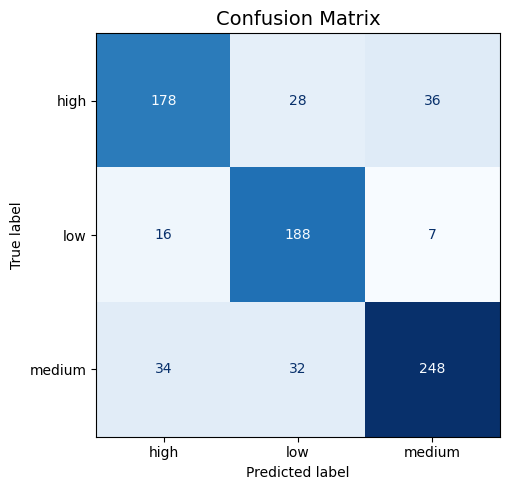

In [24]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=label_encoder.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()

## 📈 Training History Plots

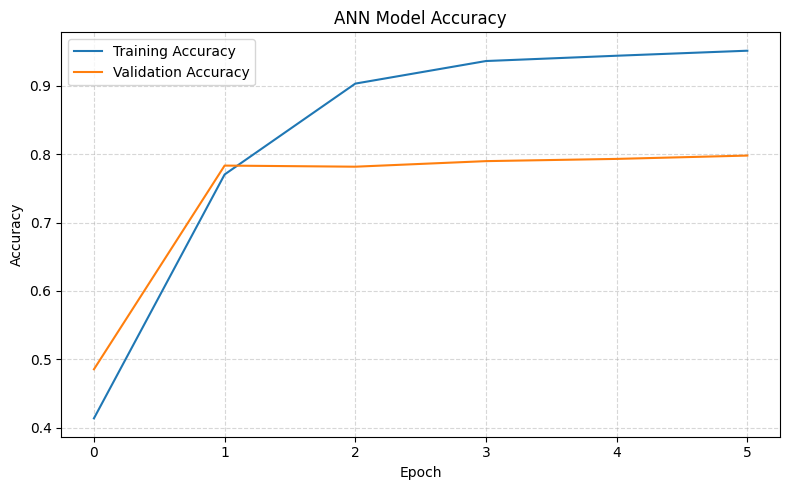

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'],     label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('ANN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

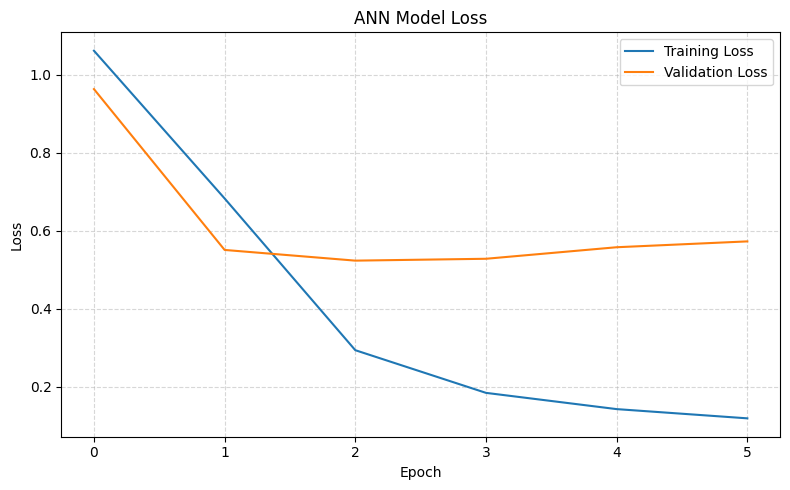

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('ANN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 💾 Save the Model (Optional)

In [27]:
# Save model to disk
model.save('ann_stress_model.h5')
print("✅ Model saved as ann_stress_model.h5")

# To download from Colab:
# from google.colab import files
# files.download('ann_stress_model.h5')

✅ Model saved as ann_stress_model.h5
